### 1. Import packages

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

from art.attacks.evasion import ZooAttack, HopSkipJump
from art.estimators.classification import XGBoostClassifier

### 2. Load data and trained model

In [2]:
# Load trained XGBoost model
xgb_model = joblib.load('../../training/models/framework_xgb_TVAE.pkl')

# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values
y_test = df_test['Label'].values.astype(int)

### 3. Original model prediction

Original Accuracy: 85.01%
Original Precision: 84.50%
Original Recall: 85.01%
Original F1 Score: 0.8448


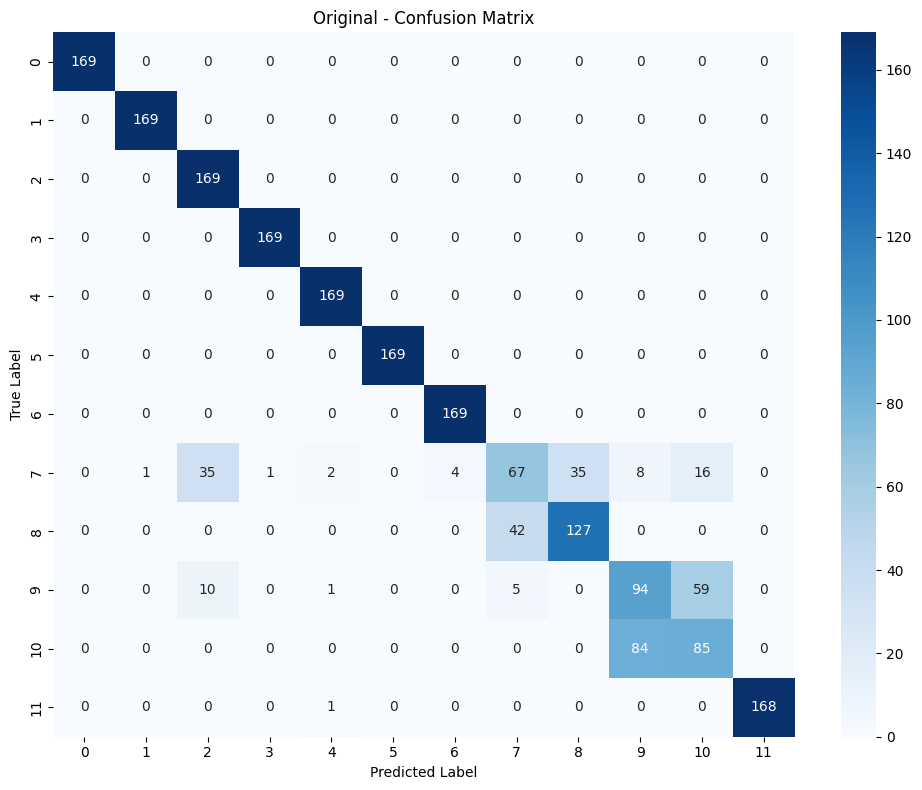

In [3]:
original_preds = xgb_model.predict_proba(df_test[df_test.columns[:-1]])
original_preds = np.argmax(original_preds, axis=1)

original_accuracy = accuracy_score(y_test, original_preds) * 100
original_f1 = f1_score(y_test, original_preds, average='weighted')
original_precision = precision_score(y_test, original_preds, average='weighted') * 100
original_recall = recall_score(y_test, original_preds, average='weighted') * 100

print(f'Original Accuracy: {original_accuracy:.2f}%')
print(f'Original Precision: {original_precision:.2f}%')
print(f'Original Recall: {original_recall:.2f}%')
print(f'Original F1 Score: {original_f1:.4f}')

cm = confusion_matrix(y_test, original_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Original - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [4]:
# Create ART classifier
classifier = XGBoostClassifier(
    model=xgb_model,
    clip_values=(np.min(X_test), np.max(X_test)),
    nb_features=X_test.shape[1],
    nb_classes=len(np.unique(y_test)),
)

predictions = classifier.predict(X_test)
predictions = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_test, predictions)
print(f'ART Classifier Accuracy: {accuracy * 100:.2f}%')

ART Classifier Accuracy: 85.01%


### 4. Generate adversarial samples

In [5]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)

    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy on {attack_name} adversarial examples: {accuracy:.2f}%')
    print(f'Precision on {attack_name} adversarial examples: {precision:.2f}%')
    print(f'Recall on {attack_name} adversarial examples: {recall:.2f}%')
    print(f'F1 Score on {attack_name} adversarial examples: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

ZOO

In [7]:
from art.attacks.evasion import ZooAttack
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=100,
    binary_search_steps=3,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_adv_samples = attack.generate(x=X_test)

ZOO: 100%|██████████| 2028/2028 [20:10<00:00,  1.68it/s]


--- ZOO ---
Accuracy on ZOO adversarial examples: 28.45%
Precision on ZOO adversarial examples: 28.73%
Recall on ZOO adversarial examples: 28.45%
F1 Score on ZOO adversarial examples: 0.2743


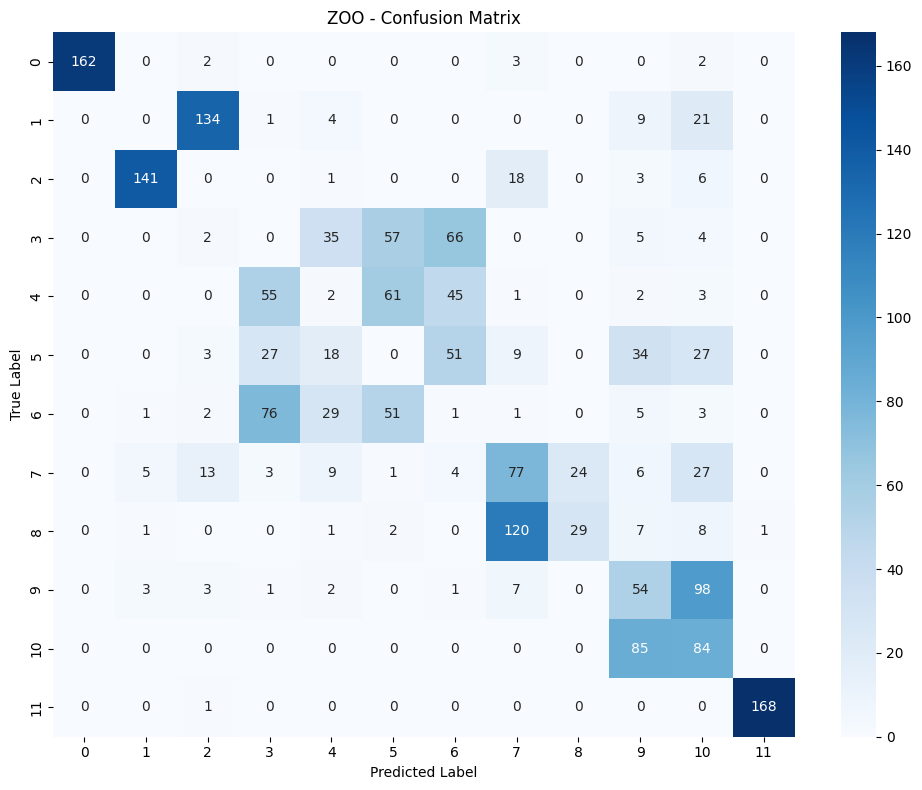

Runtime:  1729.728600025177  seconds


In [8]:
predictions_adv = classifier.predict(ZOO_adv_samples)

evaluate_attack(y_test, predictions_adv, 'ZOO')
print("Runtime: ", time.time() - start_time, " seconds")

# Save adversarial samples as CSV
feature_names = df_test.columns[:-1].tolist()
df_adv = pd.DataFrame(ZOO_adv_samples, columns=feature_names)
df_adv['Label'] = y_test
df_adv.to_csv('../../adv_samples/adv_eval/xgb/xgb_zoo_adv.csv', index=False)

HSJA

In [17]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=10,
    targeted=False,
    norm=2,
    max_iter=5,
    max_eval=100,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_adv_samples = attack.generate(x=X_test)

HopSkipJump: 100%|██████████| 2028/2028 [15:29<00:00,  2.18it/s]


--- HSJA ---
Accuracy on HSJA adversarial examples: 16.91%
Precision on HSJA adversarial examples: 14.38%
Recall on HSJA adversarial examples: 16.91%
F1 Score on HSJA adversarial examples: 0.1183


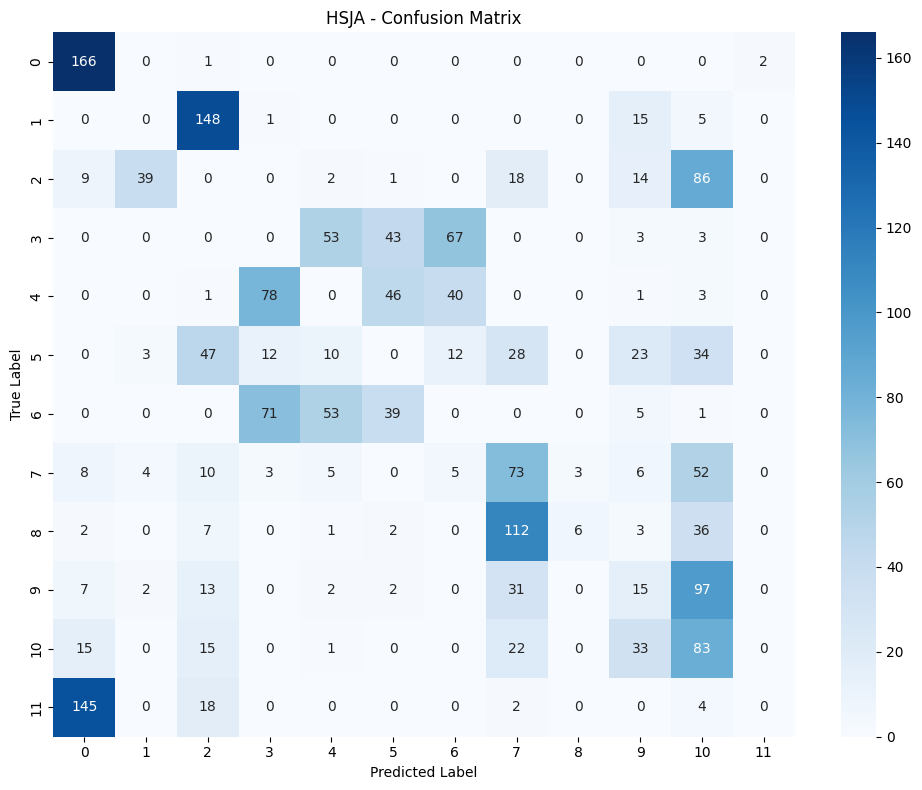

Runtime:  982.2049658298492  seconds


In [18]:
predictions_adv = classifier.predict(HSJA_adv_samples)

evaluate_attack(y_test, predictions_adv, 'HSJA')
print("Runtime: ", time.time() - start_time, " seconds")

# Save adversarial samples as CSV
df_adv = pd.DataFrame(HSJA_adv_samples, columns=feature_names)
df_adv['Label'] = y_test
df_adv.to_csv('../../adv_samples/adv_eval/xgb/xgb_hsja_adv.csv', index=False)

### 5. ASR (Attack Success Rate)

In [6]:
# Original predictions
predictions = classifier.predict(X_test)
y_pred_org = np.argmax(predictions, axis=1)

# Get correctly classified indices
correct_indices = np.where(y_test == y_pred_org)[0]

# ZOO ASR
predictions_adv_zoo = classifier.predict(ZOO_adv_samples)
y_pred_zoo = np.argmax(predictions_adv_zoo, axis=1)
asr_zoo = np.sum(y_pred_org[correct_indices] != y_pred_zoo[correct_indices]) / len(correct_indices) * 100

# HSJA ASR
predictions_adv_hsja = classifier.predict(HSJA_adv_samples)
y_pred_hsja = np.argmax(predictions_adv_hsja, axis=1)
asr_hsja = np.sum(y_pred_org[correct_indices] != y_pred_hsja[correct_indices]) / len(correct_indices) * 100

print(f'ZOO ASR: {asr_zoo:.2f}%')
print(f'HSJA ASR: {asr_hsja:.2f}%')

NameError: name 'ZOO_adv_samples' is not defined